## Probit Model - fitting and basic analysis

1. fit model and save traces
2. load traces and extract rnp, (& gamma & intercept)
    * check basic effect of session/group/interaction on  intercept/x(slope)
    * check rnp ses:group
3. plot RNP  x= ses1/ses2, hue=group0/group1 
4. plot posterior chains (gamma, intercept, RNP)
4.1. ses2-ses1 / group1-group2
4.2. diff of diff
...
check correlations, model comparison, 
look at posterior_predictive_probit

In [5]:
# env: behav_fit2 - works
# plot raw behavior in plot_rawData.ipynb

from stress_risk.behavior.utils import get_data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
import bambi
bids_folder = '/Users/mrenke/data/ds-stressrisk'

target_folder = op.join(bids_folder, 'derivatives', 'cogmodels')
df = get_data()
df['x'] = df['log(risky/safe)']



/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [6]:
# decide on model version

n_model = 1

if n_model == 1:
    formulae = 'chose_risky ~ x*session*group + (x*session|subject)' # 1
elif n_model == 2:
    formulae = 'chose_risky ~ x*session:group + (x*session|subject)' # no main effect of group # 2
elif n_model == 3:
    formulae = 'chose_risky ~ x*session + session:group + x*session:group + (x*session|subject)' # 3
elif n_model == 4:
    formulae = 'chose_risky ~ x*risky_first*n_safe*session:group + (x*risky_first*n_safe*session|subject)' # 3
elif n_model == 5:
    formulae = 'chose_risky ~ x*risky_first*C(n_safe)*C(session)*C(group) + (x*risky_first*C(n_safe)*C(session)|subject)' # 3


In [ ]:
# 1. fit probit modelling

model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

# fit
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

# save model fit
import arviz as az
az.to_netcdf(traces, op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))

In [7]:
# 2. get parameters from trace
from utils import extract_rnp_precision
import arviz as az

model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

traces= az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))
intercept, gamma = extract_rnp_precision(traces, model, df, True) # important 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)


#### check basic effect of session/group/interaction on  intercept/x(slope)

Intercept: mean=-1.4846139831849081, 95%CI=[-1.94218471 -1.04558353]
x: mean=2.034695795121376, 95%CI=[1.5593768  2.53133063]
session: mean=-0.13146532357153712, 95%CI=[-0.40798028  0.14780943]
x:session: mean=0.27552010130137833, 95%CI=[-0.02259017  0.59066959]
group: mean=-0.20748052421779314, 95%CI=[-0.8152142   0.38149853]
x:group: mean=-0.2130448509525927, 95%CI=[-0.91969024  0.48102963]
session:group: mean=0.30593465070098824, 95%CI=[-0.07959265  0.69975295]
x:session:group: mean=-0.04994294211061232, 95%CI=[-0.50436139  0.37744409]


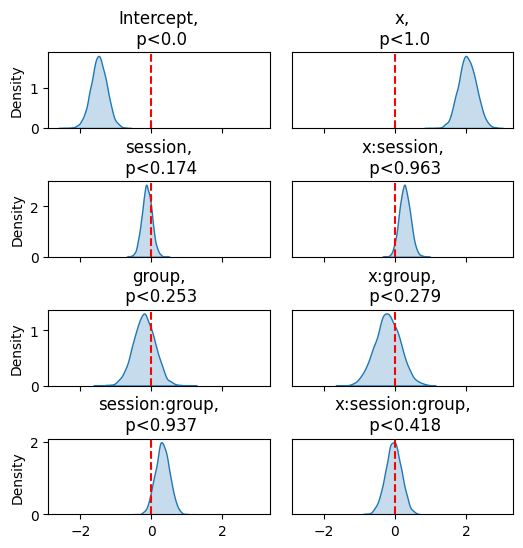

In [8]:
variable_names = list(traces.posterior.data_vars.keys())  # variable_names = list(traces.posterior.data_vars.keys()) 
fig, axs = plt.subplots(4,2, figsize=(6, 6), sharex=True)

for i in range(4):
    for j in range(2):
        index = i * 2 + j
        var = variable_names[index] # goes till 7/8
        temp = traces.posterior[var].to_dataframe()
        count_greater_zero = np.round(np.mean(temp[var] > 0),3)
        sns.kdeplot(temp, ax=axs[i, j],legend=False, fill=True)
        if j!= 0:
            axs[i, j].set(yticks=[],ylabel='')
        axs[i, j].axvline(x=0, color='r', linestyle='--')
        axs[i, j].set_title(f'{var},\n p<{count_greater_zero}')
        print(f'{var}: mean={temp[var].mean()}, 95%CI={np.percentile(temp[var], [2.5, 97.5])}')

fig.subplots_adjust(wspace=0.1, hspace=0.7)   

## RNP session:group effect 

mean=session:group    0.305935
dtype: float64, 95%CI=[-0.07959265  0.69975295], p-value=session:group    0.063
dtype: float64


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


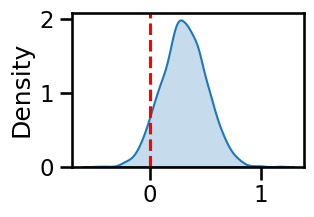

In [27]:
int_sesgroup = traces.posterior['session:group'].to_dataframe() #intercept
gamma_sesgroup = traces.posterior['x:session:group'].to_dataframe() #slope 

rnp_sesgroup = np.clip(np.exp(int_sesgroup/gamma_sesgroup), 0, 1) # rnp as a function of inertcept and slope
print(f'mean={int_sesgroup.mean()}, 95%CI={np.percentile(int_sesgroup, [2.5, 97.5])}, p-value={np.round(np.mean(int_sesgroup < 0),3)}')
fig, ax = plt.subplots(1,1, figsize=(3,2))
sns.kdeplot(int_sesgroup, fill=True,legend=False,ax=ax)
ax.axvline(x=0, color='r', linestyle='--')

mean=0.06636655042303961, 95%CI=[-0.00537761  0.1417889 ], p-value=0.034


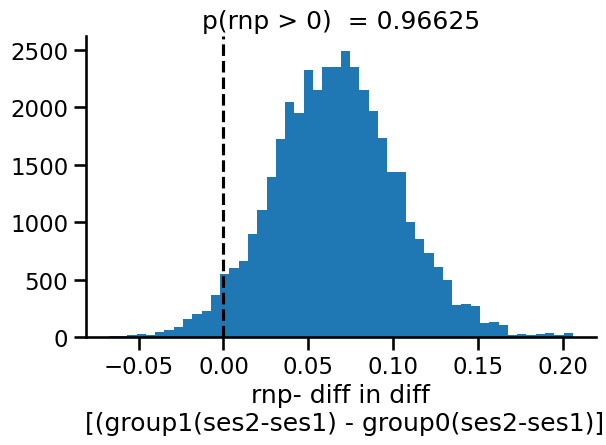

In [25]:
# from extract_rnp_precision

r = rnp.stack([1,2])
r.columns  = ['y']
r = r.reset_index()

d = r
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('rnp- diff in diff\n [(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p(rnp > 0)  = {str(np.mean(dd > 0))}')
sns.despine()
plt.tight_layout()
#plt.savefig(op.join(target_folder, 'figures', model_name, f'diffOFdiff_rnp'))
#plt.close()
print(f'mean={dd.mean()}, 95%CI={np.percentile(dd, [2.5, 97.5])}, p-value={np.round(np.mean(dd < 0),3)}')


## Visualize shifts

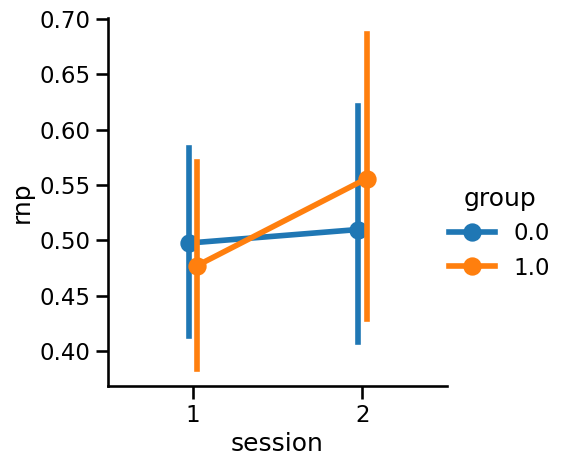

In [15]:
from arviz import hdi
sns.set_context('talk')

get_error_bar = lambda d: hdi(d.values)
tmp = rnp.stack([-1, -2])
tmp.columns = ['rnp']
tmp = tmp.reset_index()
sns.catplot(tmp, y='rnp', x='session', hue='group', kind='point',
            errorbar=get_error_bar, dodge=True) # x='n_safe', y='rnp', hue='session', col='group', row='risky_first'

In [17]:
print(rnp.groupby(['session', 'group']).mean().mean(axis=1))
print(rnp.groupby(['session', 'group']).mean().std(axis=1))

# 95%CI={np.percentile(df_1e_ses, [2.5, 97.5])}')

session  group
1        0.0      0.497494
         1.0      0.477118
2        0.0      0.509737
         1.0      0.555728
dtype: float64
session  group
1        0.0      0.045035
         1.0      0.049994
2        0.0      0.056538
         1.0      0.069089
dtype: float64


In [29]:
# 4. plot posterior estimates
import os

model_name = f'bambi-RNP-fit_model{n_model}'
if not op.exists(op.join(target_folder, 'figures',model_name)):
    os.makedirs(op.join(target_folder, 'figures',model_name))

g = gamma.stack([1,2])
g.columns  = ['gamma']
g = g.reset_index()

i = intercept.stack([1,2])
i.columns  = ['intercept']
i = i.reset_index()

r = rnp.stack([1,2])
r.columns  = ['y']
r = r.reset_index()



In [46]:
# single differences
sns.set_context('talk')

# gamma
d = g
for group in [0,1]:
    dd= np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('gamma')
    plt.title(f'group{group}, ses2 - ses1, p={np.mean(dd>0)}')
    np.mean(dd>0)
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'gamma_group{group}_ses1-ses2'))
    plt.close()

for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['gamma']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['gamma'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('gamma')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'gamma_session{ses}_group1-group0'))
    plt.close()

# intercept
d = i
for group in [0,1]:
    dd= np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('intercept')
    plt.title(f'group{group}, ses2 - ses1, p={np.mean(dd>0)}')
    np.mean(dd>0)
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'intercept_group{group}_ses1-ses2'))
    plt.close()


for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['intercept']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['intercept'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('intercept')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'intercept_session{ses}_group1-group0'))
    plt.close()

# rnp
d = r
for group in [0,1]:
    dd= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('rnp')
    plt.title(f'group{group}, ses2 - ses1,p={np.mean(dd>0)}')
    np.mean(dd>0)
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'rnp_group{group}_ses1-ses2'))
    plt.close()


for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['y']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['y'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('rnp')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'rnp_session{ses}_group1-group0'))
    plt.close()


In [47]:
# diff in diff
sns.set_context('talk')
# gamma
d = g
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('gamma - diff in diff\n [(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p(gamma > 0)  = {str(np.mean(dd > 0))}')
plt.tight_layout()
sns.despine()
plt.savefig(op.join(target_folder, 'figures',model_name, f'diffOFdiff_gamma'))
plt.close()

# intercept
d = i
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('intercept- diff in diff\n[(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p(intercept > 0)  = {str(np.mean(dd > 0))}')
plt.tight_layout()
sns.despine()
plt.savefig(op.join(target_folder, 'figures',model_name, f'diffOFdiff_intercept'))
plt.close()

# rnp
#rnp = np.clip(np.exp(intercept/gamma), 0, 1)
d = r
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('rnp- diff in diff\n [(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p(rnp > 0)  = {str(np.mean(dd > 0))}')
sns.despine()
plt.tight_layout()
plt.savefig(op.join(target_folder, 'figures', model_name, f'diffOFdiff_rnp'))
plt.close()


In [14]:
# save parameters
intercept, gamma = extract_rnp_precision(traces, model, df, False) # 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)

n_model = 'tryout'
gamma_ = gamma.stack([1, 2]).groupby(['subject', 'session']).mean()
gamma_.columns = ['gamma']

intercept_ = intercept.stack([1, 2]).groupby(['subject', 'session']).mean()
intercept_.columns = ['intercept']

rnp_ = rnp.stack([1, 2]).groupby(['subject', 'session']).mean()
rnp_.columns = ['rnp']

params = rnp_.join(gamma_).join(intercept_)
params.to_csv(op.join(target_folder, 'param_estimates', f'bambi-{n_model}_subseswise_params.csv'))



/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [ ]:
# correlation of rnp and gamma
sns.lmplot(x='rnp', y='gamma', data=params)

In [ ]:
# model comparison

import arviz as az
data1 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model1.netcdf'))
data2 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model2.netcdf'))
data3 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model3.netcdf'))

compare_dict = {"model 1": data1, "model 2": data2,"model 3": data3}
az.compare(compare_dict)

In [4]:
# check parameter file
df_probit_params = pd.read_csv(f'/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates/bambi-{n_model}_subseswise_params.csv')
df_cond = pd.read_excel('/Users/mrenke/data/ds-stressrisk/addMeasures/data_combined.xlsx')

In [5]:
groups = df_cond.rename(columns={'SUBID':'subject', 'condition':'group'}).set_index('subject')[['group']]
tmp = df_probit_params.set_index(['subject', 'session']).join(groups)

tmp

rnp     gamma  intercept  group
subject session                                      
1       1        0.600260  2.892456  -1.481595      0
        2        0.600111  3.229501  -1.669011      0
2       1        0.545680  2.609244  -1.590322      0
        2        0.684008  3.074884  -1.214223      0
3       1        0.521614  1.813866  -1.181555      1
...                   ...       ...        ...    ...
58      2        0.483389  2.132658  -1.579862      1
59      1        0.387507  2.525307  -2.395071      0
        2        0.464295  3.088420  -2.400178      0
61      1        0.583817  2.571492  -1.393990      0
        2        0.611670  2.748749  -1.388498      0

[100 rows x 4 columns]

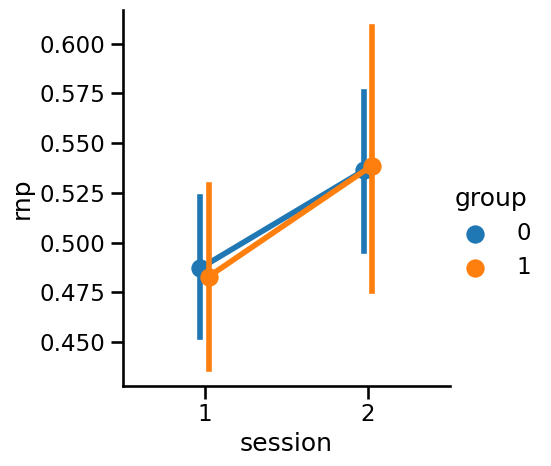

In [7]:
# shouldnt do group statistics on subject wise parameters from a hierahical model !!!
tmp_ = tmp.reset_index().copy()
#tmp_.loc[tmp_.group == 1, 'subject'] +=  100
sns.set_context('talk')
sns.catplot(tmp_, x='session', y='rnp', hue='group',kind='point',dodge=True) #kind='point',


Text(0.5, 1.0, 'group 0')

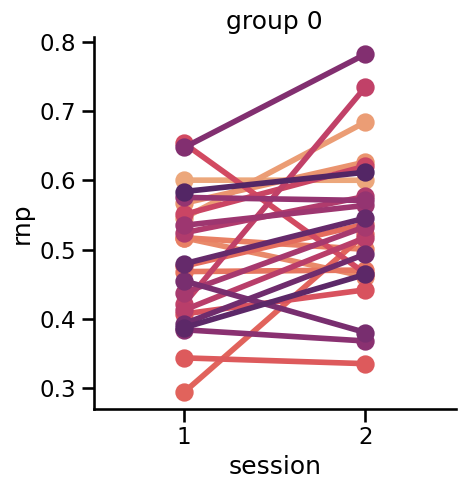

In [16]:
tmp_ = tmp.reset_index().copy()
#tmp_.loc[tmp_.group == 1, 'subject'] +=  100
#fig, ax = plt.subplots()

sns.catplot(tmp_[tmp_.group ==0], x='session', y='rnp', hue='subject',kind='point', palette="flare",legend=False) #,ax=ax) #kind='point',
plt.title('group 0')

Text(0.5, 1.0, 'group 1')

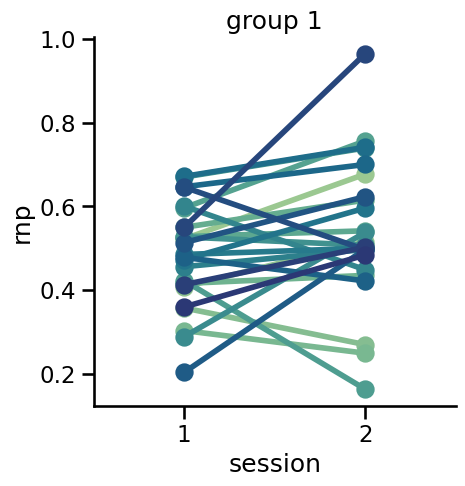

In [17]:
sns.catplot(tmp_[tmp_.group ==1], x='session', y='rnp', hue='subject',kind='point', palette="crest",legend=False) #,ax=ax2) #kind='point',
plt.title('group 1')

In [13]:
tmp_[tmp_.group ==1]

,subject,session,rnp,gamma,intercept,group
4,3,1,0.521614,1.813866,-1.181555,1
5,3,2,0.676851,2.028591,-0.822728,1
6,4,1,0.407144,2.393254,-2.151008,1
7,4,2,0.514954,2.896022,-1.940604,1
16,13,1,0.356751,2.056016,-2.115630,1
17,13,2,0.269023,2.067174,-2.703694,1
18,14,1,0.302690,2.082064,-2.481263,1
19,14,2,0.248562,2.124656,-2.945913,1
24,18,1,0.415294,2.441469,-2.139404,1
25,18,2,0.434648,2.784527,-2.323809,1
